# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourhood               30478 non-null  object 
 4   Property Type               30475 non-null  object 
 5   Review Scores Rating (bin)  22155 non-null  float64
 6   Room Type                   30478 non-null  object 
 7   Zipcode                     30344 non-null  float64
 8   Beds                        30393 non-null  float64
 9   Number of Records           30478 non-null  int64  
 10  Number Of Reviews           30478 non-null  int64  
 11  Price                       30478 non-null  object 
 12  Review Scores Rating        22155 non-null  float64
dtypes: float64(4), int64(3), object

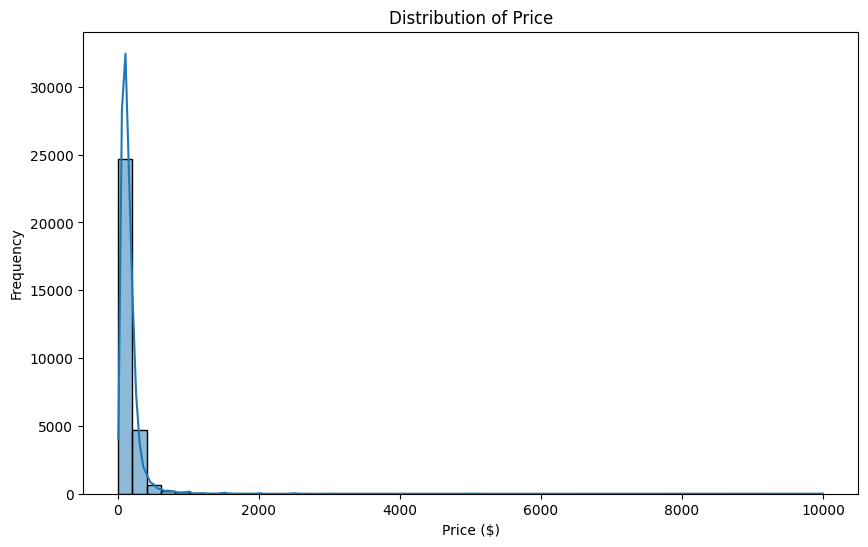

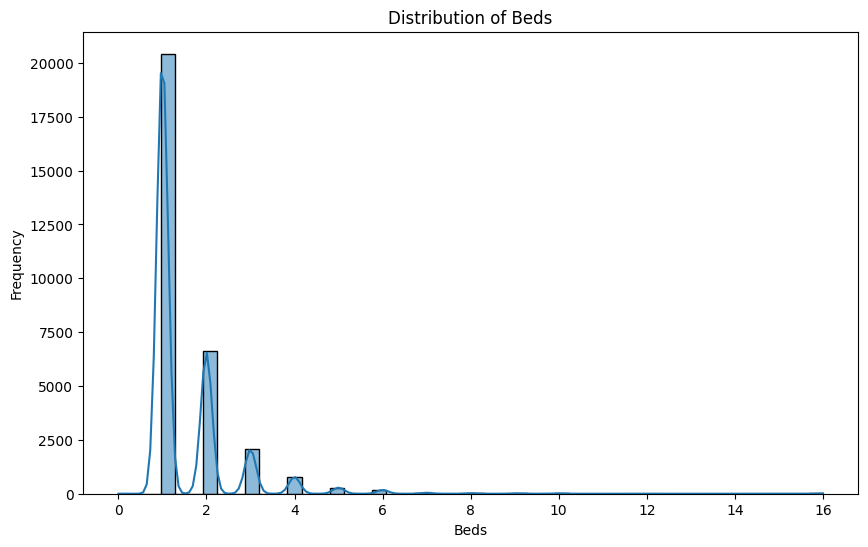

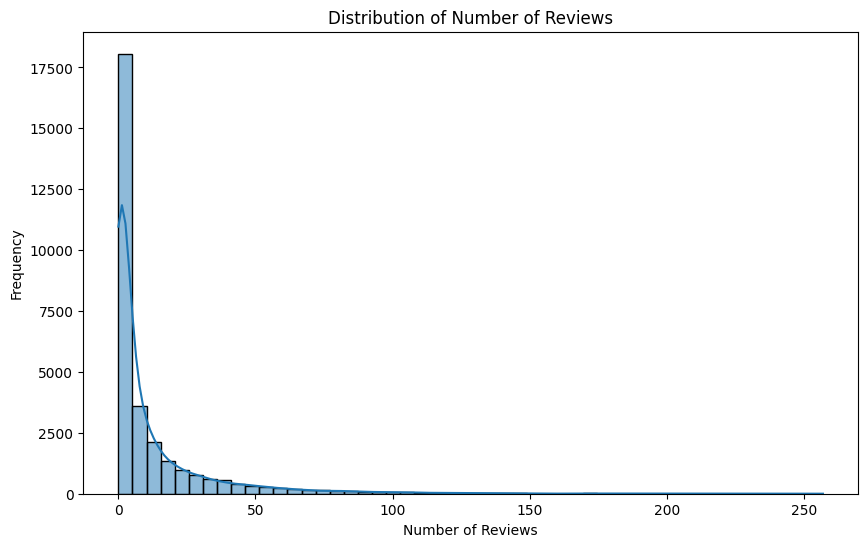

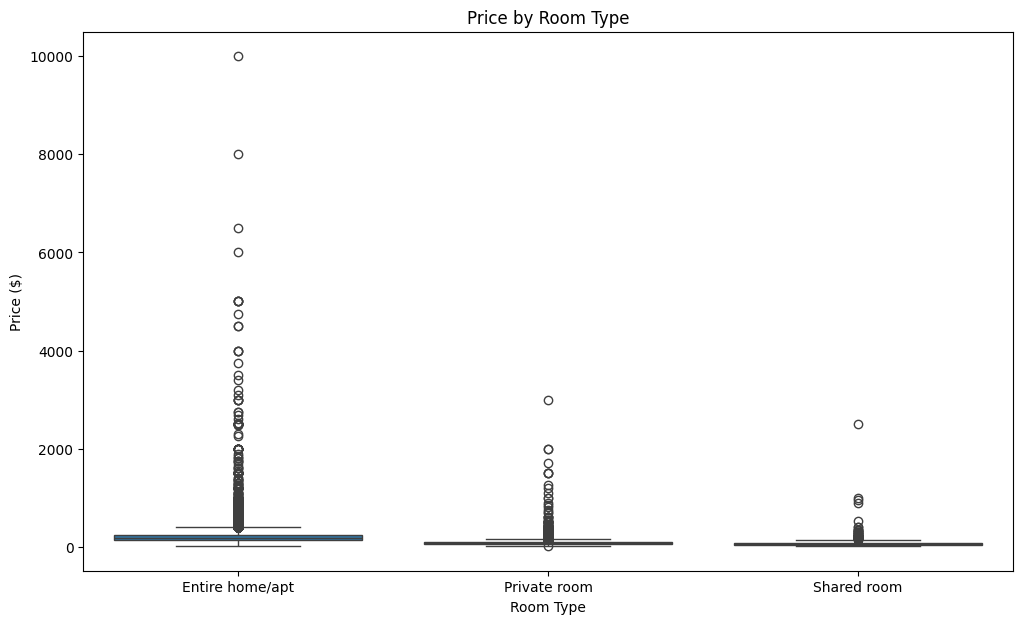

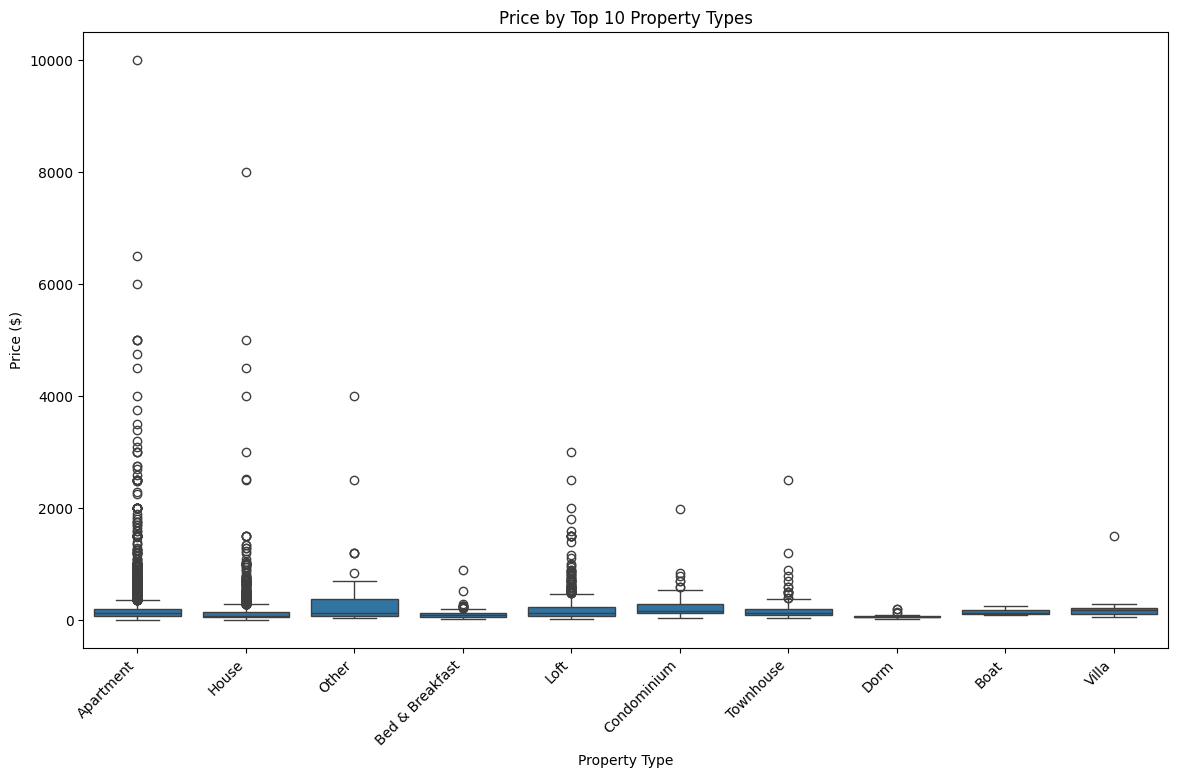

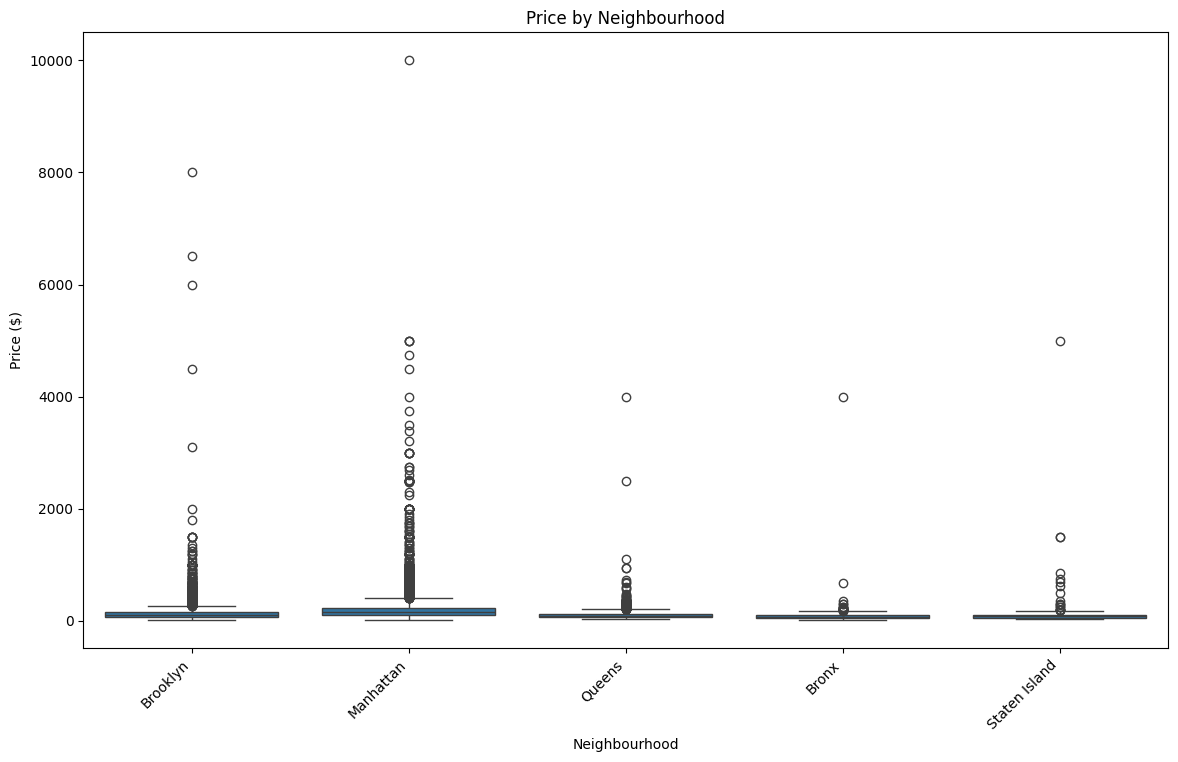

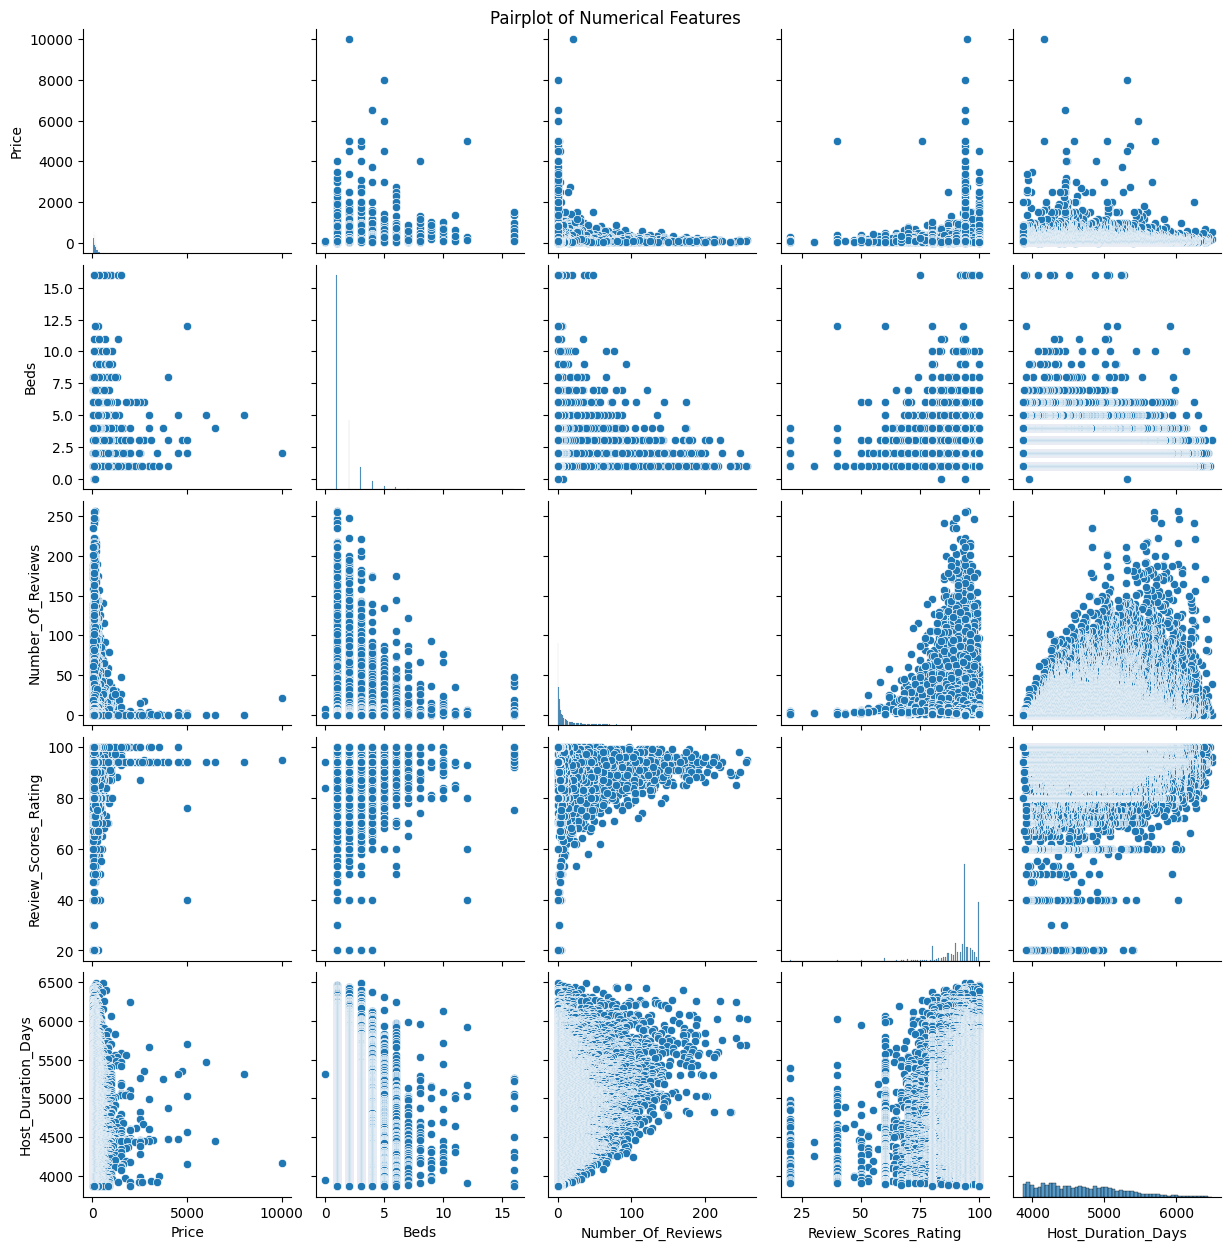

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# 1
airbnb = pd.read_csv("airbnb_hw.csv")
airbnb.info()
airbnb.describe(include='all')
airbnb.isnull().sum()
# according to info, all numeric variables are numeric except for price
airbnb['Price'] = pd.to_numeric(airbnb['Price'].str.replace(',', ''), errors='coerce')
# the 'Host Since' field is also an object, so I want to convert it to a datetime value
airbnb['Host Since'] = pd.to_datetime(airbnb['Host Since'], errors='coerce')

# next, I want to fill in any missing values
airbnb['Beds'] = airbnb['Beds'].fillna(airbnb['Beds'].median())
airbnb['Zipcode'] = airbnb['Zipcode'].fillna(airbnb['Zipcode'].mode()[0])
airbnb['Host Since'] = airbnb['Host Since'].fillna(airbnb['Host Since'].mode()[0])
airbnb['Host_Duration_Days'] = (pd.to_datetime('today')-airbnb['Host Since']).dt.days
airbnb['Property Type'] = airbnb['Property Type'].fillna(airbnb['Property Type'].mode()[0])
airbnb['Review Scores Rating'] = airbnb['Review Scores Rating'].fillna(airbnb['Review Scores Rating'].median())
airbnb = airbnb.drop(columns=['Review Scores Rating (bin)'])
airbnb = airbnb.drop(columns=['Name'])

airbnb = airbnb.rename(columns={
    'Number Of Reviews': 'Number_Of_Reviews',
    'Neighbourhood ': 'Neighbourhood',
    'Review Scores Rating': 'Review_Scores_Rating'
})

print("Updated DataFrame info after data cleaning and column renaming:")
airbnb.info()
print("\nMissing values after cleaning:")
print(airbnb.isnull().sum())

# I now want to display all my visualizations
plt.figure(figsize=(10, 6))
sns.histplot(airbnb['Price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(airbnb['Beds'], bins=50, kde=True)
plt.title('Distribution of Beds')
plt.xlabel('Beds')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(airbnb['Number_Of_Reviews'],bins=50,kde=True)
plt.title('Distribution of Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.show()

# price vs room types
plt.figure(figsize=(12, 7))
sns.boxplot(x='Room Type', y='Price', data=airbnb)
plt.title('Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.show()

# price vs top 10 property type
plt.figure(figsize=(14, 8))
top_property_types = airbnb['Property Type'].value_counts().nlargest(10).index
sns.boxplot(x='Property Type', y='Price', data=airbnb[airbnb['Property Type'].isin(top_property_types)])
plt.title('Price by Top 10 Property Types')
plt.xlabel('Property Type')
plt.ylabel('Price ($)')
plt.xticks(rotation=45, ha='right')
plt.show()


# price vs neighborhood
plt.figure(figsize=(14, 8))
sns.boxplot(x='Neighbourhood', y='Price', data=airbnb)
plt.title('Price by Neighbourhood')
plt.xlabel('Neighbourhood')
plt.ylabel('Price ($)')
plt.xticks(rotation=45, ha='right')
plt.show()

# checking correlations for all numerical variables using pairplots
numeric_cols = ['Price', 'Beds', 'Number_Of_Reviews', 'Review_Scores_Rating', 'Host_Duration_Days']
sns.pairplot(airbnb[numeric_cols])
plt.suptitle('Pairplot of Numerical Features',y=1)
plt.show()

In [67]:
# 2

# we need to transform categorical variables into a numerical format that's suitable for regression, which we can use one-hot encoding for

categorical = ['Neighbourhood', 'Property Type', 'Room Type', 'Zipcode']
airbnb_onehot = pd.get_dummies(airbnb, columns=categorical, drop_first=True)

print("The original number of columns is ", airbnb.shape[1])
print("The number of columns after one-hot encoding is ", airbnb_onehot.shape[1])
print("The first 5 rows of encoded data:")
display(airbnb_onehot.head())

The original number of columns is  12
The number of columns after one-hot encoding is  219
The first 5 rows of encoded data:


,Host Id,Host Since,Beds,Number of Records,Number_Of_Reviews,Price,Review_Scores_Rating,Host_Duration_Days,Neighbourhood_Brooklyn,Neighbourhood_Manhattan,...,Zipcode_11433.0,Zipcode_11434.0,Zipcode_11435.0,Zipcode_11436.0,Zipcode_11691.0,Zipcode_11692.0,Zipcode_11693.0,Zipcode_11694.0,Zipcode_94103.0,Zipcode_99135.0
0,5162530,2014-02-10,1.0,1,0,145,94.0,4434,True,False,...,False,False,False,False,False,False,False,False,False,False
1,33134899,2014-02-10,1.0,1,1,37,94.0,4434,True,False,...,False,False,False,False,False,False,False,False,False,False
2,39608626,2014-02-10,1.0,1,1,28,94.0,4434,False,True,...,False,False,False,False,False,False,False,False,False,False
3,500,2008-06-26,3.0,1,0,199,94.0,6489,False,True,...,False,False,False,False,False,False,False,False,False,False
4,500,2008-06-26,3.0,1,39,549,96.0,6489,False,True,...,False,False,False,False,False,False,False,False,False,False


In [68]:
# 3

# we need to split the data into training and testing sets (80/20 split). the target variable is Price

X = airbnb_onehot.drop(columns=['Price','Host Since'])
y = airbnb_onehot['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)

Shape of X_train:  (24382, 217)
Shape of X_test:  (6096, 217)
Shape of y_train:  (24382,)
Shape of y_test:  (6096,)


In [69]:
# 4

from sklearn.linear_model import LinearRegression

# we're going to build some simple linear models using a few specific variables, without any transformations or
# interaction features. we're going to evaluate their performance using RMSE and R-squared on both the training
# and testing sets.

# Linear Model 1: Only examining 'Beds'
model_1 = LinearRegression()
feature1 = ['Beds']
model_1.fit(X_train[feature1], y_train)

y_pred_train1 = model_1.predict(X_train[feature1])
y_pred_test1 = model_1.predict(X_test[feature1])
rmse_train1 = np.sqrt(mean_squared_error(y_train, y_pred_train1))
r2_train1 = r2_score(y_train, y_pred_train1)
rmse_test1 = np.sqrt(mean_squared_error(y_test, y_pred_test1))
r2_test1 = r2_score(y_test, y_pred_test1)
print("Model 1 (Beds Only):")
print("Train RMSE: ", rmse_train1, "R^2: ", r2_train1)
print("Test RMSE: ", rmse_test1, "R^2: ", r2_test1)

# Linear Model 2: Examining 'Beds' and 'Number_Of_Reviews'
model_2 = LinearRegression()
features2 = ['Beds','Number_Of_Reviews']
model_2.fit(X_train[features2], y_train)

y_pred_train2 = model_2.predict(X_train[features2])
y_pred_test2 = model_2.predict(X_test[features2])
rmse_train2 = np.sqrt(mean_squared_error(y_train, y_pred_train2))
r2_train2 = r2_score(y_train, y_pred_train2)
rmse_test2 = np.sqrt(mean_squared_error(y_test, y_pred_test2))
r2_test2 = r2_score(y_test, y_pred_test2)
print("Model 2 (Beds and Number of Reviews):")
print("Train RMSE: ", rmse_train2, "R^2: ", r2_train2)
print("Test RMSE: ", rmse_test2, "R^2: ", r2_test2)

# Linear Model 3: Examining 'Beds', 'Number_Of_Reviews', 'Review_Scores_Rating', 'Host_Duration_Days' and Room Type (one-hot encoded version)
model_3 = LinearRegression()
room_type_cols = [col for col in X_train.columns if 'Room Type_' in col]
features3 = ['Beds','Number_Of_Reviews','Review_Scores_Rating','Host_Duration_Days'] + room_type_cols
model_3.fit(X_train[features3], y_train)

y_pred_train3 = model_3.predict(X_train[features3])
y_pred_test3 = model_3.predict(X_test[features3])
rmse_train3 = np.sqrt(mean_squared_error(y_train, y_pred_train3))
r2_train3 = r2_score(y_train, y_pred_train3)
rmse_test3 = np.sqrt(mean_squared_error(y_test, y_pred_test3))
r2_test3 = r2_score(y_test, y_pred_test3)
print("Model 3 (Multiple Features):")
print("Train RMSE: ", rmse_train3, "R^2: ", r2_train3)
print("Test RMSE: ", rmse_test3, "R^2: ", r2_test3)

# After comparing all three models, Model 3 performs the best, with the lowest RMSE values and the highest
# R-squared values. This suggests that the additional features contribute to better conditions.

Model 1 (Beds Only):
Train RMSE:  186.69991622708855 R^2:  0.09324833802504084
Test RMSE:  192.02978305745788 R^2:  0.11813124473239811
Model 2 (Beds and Number of Reviews):
Train RMSE:  186.40249348718876 R^2:  0.09613504258451899
Test RMSE:  191.63584325433897 R^2:  0.12174575554290257
Model 3 (Multiple Features):
Train RMSE:  180.25811610053304 R^2:  0.15474106574496826
Test RMSE:  185.18635499897223 R^2:  0.17986614398566836


<Figure size 800x600 with 0 Axes>

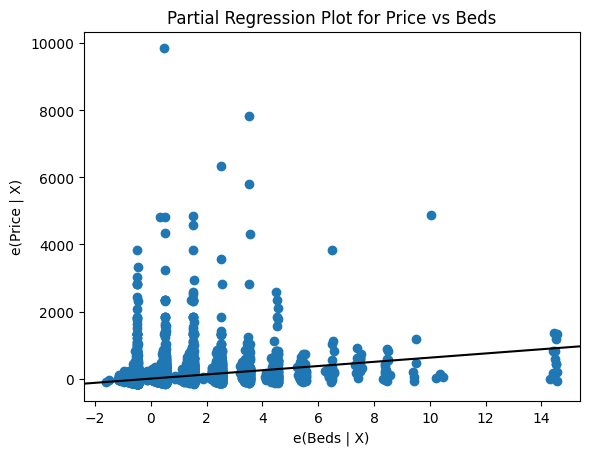

<Figure size 800x600 with 0 Axes>

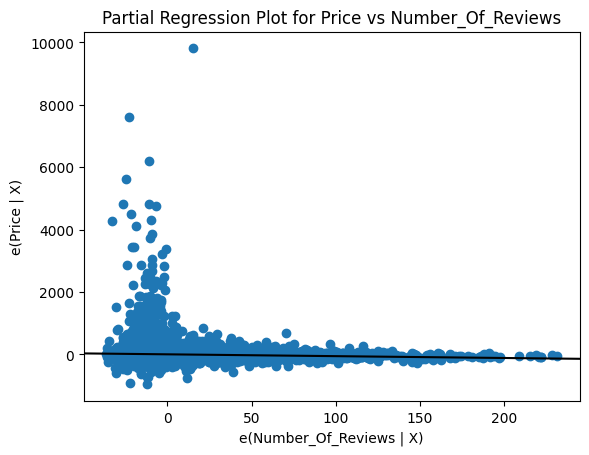

<Figure size 800x600 with 0 Axes>

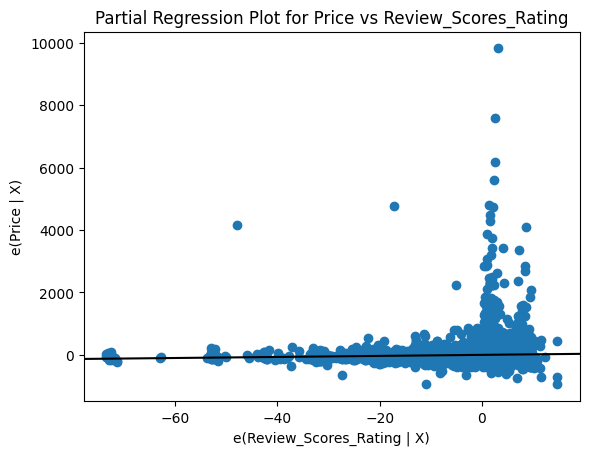

<Figure size 800x600 with 0 Axes>

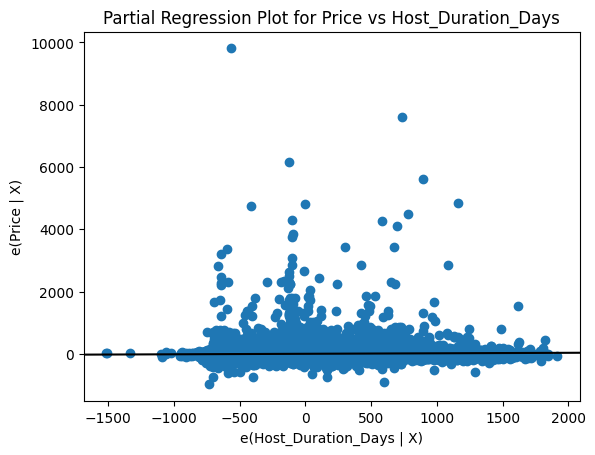

In [70]:
# 5

# To identify non-linear relationships and interactions, it's helpful to display partial correlation plots.

partial_correlation_vars = ['Beds','Number_Of_Reviews','Review_Scores_Rating','Host_Duration_Days']
df_partial_corr = airbnb_onehot[partial_correlation_vars+['Price']]
for var in partial_correlation_vars:
    fig = plt.figure(figsize=(8,6))
    fig = sm.graphics.plot_partregress(
        endog='Price',
        exog_i=var,
        exog_others=[v for v in partial_correlation_vars if v != var],
        data=df_partial_corr,
        obs_labels=False
    )
    plt.title(f'Partial Regression Plot for Price vs {var}')
    plt.show()

    # Looking at the partial correlation plots shows us that some variables show slightly non-linear patterns,
    # suggesting that transformations and interactions would be helpful in making a better model. For example,
    # Number of Reviews and Review Score Ratings could benefit from a log transformation or more polynomial
    # terms if their relationship with Price isn't purely linear.

In [71]:
# 6

# To build a more complex model, we can incorporate a log transformation for Price and potentially some other
# features to address skewed distributions or non-linearities. Furthermore, we could add polynomial features
# for Beds, Number of Reviews, and Host Duration Days, or interaction terms between key features. We can then
# re-evaluate the RMSE and R^2 values.

airbnb_complex = airbnb_onehot.copy()
airbnb_complex['Log_Price'] = np.log1p(airbnb_complex['Price'])
X_complex = airbnb_complex.drop(columns=['Price', 'Log_Price', 'Host Since'])
y_complex = airbnb_complex['Log_Price']

X_train_complex, X_test_complex, y_train_complex, y_test_complex = train_test_split(X_complex, y_complex, test_size=0.2, random_state=42)
numeric_features = ['Beds', 'Number_Of_Reviews', 'Review_Scores_Rating', 'Host_Duration_Days']
categorical_features_encoded = [col for col in X_train_complex.columns if col not in numeric_features]
preProcessor = ColumnTransformer(transformers=[ ('poly', PolynomialFeatures(degree=2, include_bias=False), numeric_features), ('passthrough', 'passthrough', categorical_features_encoded)],remainder='passthrough')
model_complex_pipeline = Pipeline(steps=[('preprocessor', preProcessor),('regressor', LinearRegression())])
model_complex_pipeline.fit(X_train_complex, y_train_complex)
y_pred_train_complex_log = model_complex_pipeline.predict(X_train_complex)
y_pred_test_complex_log = model_complex_pipeline.predict(X_test_complex)

y_pred_train_complex = np.expm1(y_pred_train_complex_log)
y_pred_test_complex = np.expm1(y_pred_test_complex_log)

rmse_train_complex = np.sqrt(mean_squared_error(np.expm1(y_train_complex), y_pred_train_complex))
r2_train_complex = r2_score(np.expm1(y_train_complex), y_pred_train_complex)
rmse_test_complex = np.sqrt(mean_squared_error(np.expm1(y_test_complex), y_pred_test_complex))
r2_test_complex = r2_score(np.expm1(y_test_complex), y_pred_test_complex)

print("Complex Model (Log Price, Polynomial Features, Interactions):")
print("Train RMSE: ",rmse_train_complex, "R^2: ",r2_train_complex)
print("Test RMSE: ",rmse_test_complex, "R^2: ",r2_test_complex)

# Comparing the complex model with the simpler ones shows an improved performance (aka a lower RMSE and a
# higher R^2). This suggests that the transformations and inclusion of higher-order terms captured more
# complex relationships in the data. The gap between the train and test performance is relatively small,
# indicating that the model isn't severely overfitting, but that there is still some tuning that could be done.


Complex Model (Log Price, Polynomial Features, Interactions):
Train RMSE:  172.70568161031548 R^2:  0.22408639979393108
Test RMSE:  178.7846667241784 R^2:  0.23558832460967438


7. Summary of Results
Thus far, I have:

*   Cleaned and Data and performed EDA: I cleaned the data, handing any missing vlaues and converting certain data types (like Hosted Since). The EDA revealed a skewed price distribution that we addressed with a log transformation and varying price ranges across different room types and neighborhoods. We also one-hot encoded categorical variables and created a Host_Duration_Days feature that stores the number of days the Host has owned the property.
*   Built the Model: I started with some basic linear regression models. Model 3, which incorporated Beds, Number of Reviews, Review Scores Rating, Host Duration Days, and Room Type showed the best performance compared to just evaluating Beds or Beds and Number of Reviews. This highlighted the importance of including more relevant features, which I further explored later in the process.
*   Created Partial Correlation Plots: I created some partial correlation plots among the numerical variables, which suggest potential non-linear relationships.
*   Created a Complex Model: I introduced a log transformation on Price (the target variable) and polynomial features for some of the key numerical predictors. This led to a much better fit (a lower RMSE and a higher R^2) on both the training and the tests sets. This indicated to me that accounting for non-linear relationships and interactions improve predictive power.
*   Conclusions: The simple models likely suffered from underfitting because they didn't capture the sufficient amount of complexity in the data, resulting in a high RMSE and low R^2. Though the complex model performed better, it also needs careful monitoring to avoid overfitting. The test performance is currently reasonable close to the training performance, which suggests a good balance, but adding too many interaction or high-polynomial terms could lead to overfitting on the training data. So, based on the number, the complex model is better for prediction. However, is interpretability is out primary goal, a simpler model might be preferred even if its poorer at prediction. If we want pure prediction power, the more complex model is the best choice.




In [72]:
# 8

# LASSO stands for Least Absolute Shrinkage and Selection Operator, and LASSO regularization adds a penalty that's
# equal to the absolute value of the magnitude of coefficients. This technique can perform feature selection
# by shrinking some coefficients to zero, which effectively removes those features from the model. We'll apply
# LASSO to the complex model's preprocessed features.

numeric_features = ['Beds', 'Number_Of_Reviews', 'Review_Scores_Rating', 'Host_Duration_Days']
categorical_encoded = [col for col in X_train_complex.columns if col not in numeric_features]

preprocessor_lasso = ColumnTransformer(transformers = [('poly', PolynomialFeatures(degree=2, include_bias=False), numeric_features),('passthrough','passthrough',categorical_encoded)
],remainder='passthrough')

model_lasso = Pipeline(steps=[('preprocessor', preprocessor_lasso),('scaler', StandardScaler()), ('regressor', Lasso(alpha=0.01, random_state=42, max_iter=2000)) # Lasso with a chosen alpha
])

model_lasso.fit(X_train_complex, y_train_complex)
y_pred_train_lasso_log = model_lasso.predict(X_train_complex)
y_pred_test_lasso_log = model_lasso.predict(X_test_complex)
y_pred_train_lasso = np.expm1(y_pred_train_lasso_log)
y_pred_test_lasso = np.expm1(y_pred_test_lasso_log)

rmse_train_lasso = np.sqrt(mean_squared_error(np.expm1(y_train_complex), y_pred_train_lasso))
r2_train_lasso = r2_score(np.expm1(y_train_complex), y_pred_train_lasso)
rmse_test_lasso = np.sqrt(mean_squared_error(np.expm1(y_test_complex), y_pred_test_lasso))
r2_test_lasso = r2_score(np.expm1(y_test_complex), y_pred_test_lasso)

print("Lasso Regularized Model:")
print("Train RMSE: ",rmse_train_lasso, "R^2: ",r2_train_lasso)
print("Test RMSE: ",rmse_test_lasso, "R^2: ",r2_test_lasso)

feature_names_transformed = model_lasso.named_steps['preprocessor'].get_feature_names_out()
lasso_coefficients = model_lasso.named_steps['regressor'].coef_
coeff_series = pd.Series(lasso_coefficients, index=feature_names_transformed)
selected_features = coeff_series[coeff_series != 0]

print("Number of features before Lasso: ",len(feature_names_transformed))
print("Number of features selected by Lasso (non-zero coefficients): ",len(selected_features))
print("Top 10 most predictive features (by absolute coefficient value):")
display(selected_features.abs().sort_values(ascending=False).head(10))

# The LASSO regularization helps in shrinking the coefficients of less important features (to zero). This effectively
# performs feature selection. The RMSE and R^2 for the LASSO model are comparable to the complex linear model.
# This suggests that it maintains predictive power while potentially offering a more stingy model by reducing
# the number of active features. The top selected features (those with non-zero coefficients) provide insight
# into which variables are most impactful on the predicted Log_Price.

Lasso Regularized Model:
Train RMSE:  177.00526723418466 R^2:  0.18497206526856802
Test RMSE:  183.3959544932291 R^2:  0.1956477592640138
Number of features before Lasso:  227
Number of features selected by Lasso (non-zero coefficients):  67
Top 10 most predictive features (by absolute coefficient value):


,0
passthrough__Room Type_Private room,0.269363
passthrough__Neighbourhood_Manhattan,0.196966
poly__Beds Review_Scores_Rating,0.152665
passthrough__Room Type_Shared room,0.129739
passthrough__Zipcode_11211.0,0.045179
passthrough__Zipcode_10031.0,0.041627
passthrough__Zipcode_11249.0,0.038832
passthrough__Zipcode_11201.0,0.029429
passthrough__Zipcode_10040.0,0.028844
passthrough__Zipcode_10032.0,0.028636


The Lasso regularization helps in shrinking the coefficients of less important features to zero, effectively performing feature selection. The RMSE and R^2 values for the Lasso model are comparable to the complex linear model, suggesting that it maintains predictive power while potentially offering a more parsimonious model by reducing the number of active features. The top selected features (those with non-zero coefficients) provide insight into which variables are most impactful on the predicted `Log_Price`.